# 05 — Avaliação

**Objetivo:** Consolidar as métricas finais, perfilizar e nomear as 6 personas, cruzar persona × gênero (qui-quadrado) e extrair regras interpretáveis com um surrogate DecisionTree (92.5% de fidelidade).

**Inputs:** `models/pipeline_final.joblib, data/processed/features_scaled.parquet, data/processed/dados_clusterizados.parquet`

**Outputs:** `models/personas.json, data/processed/dados_clusterizados.parquet, reports/figures/*.png`

---

**Roteiro:**

1. Setup, tema e configurações locais e globais
2. Carregamendo dos dados e métricas finais
3. Perfilização dos clusters
4. Gráfico de perfil das personas
5. Mapeamento de personas
6. Cruzamento Persona × Gênero
7. Surrogate DecisionTree
8. Visualização: árvore surrogate + clusters no PCA
9. Re-salvar clusterizado + exportar dicionário de personas
10. 10 — Fechamento

### Etapa 1 - Setup, tema e configurações locais e globais

In [1]:
import json
import re

import joblib
from math import pi
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency
from sklearn.metrics import(
    accuracy_score, calinski_harabasz_score, classification_report,
    davies_bouldin_score, silhouette_samples, silhouette_score,
)
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

from src.config import CONFIG, CAMINHOS
from src.viz_config import PALETTE, CORES

DADOS_PRO    = CAMINHOS.dados_processed
MODELS_DIR   = CAMINHOS.modelos
FIG_DIR  = CAMINHOS.figures
RANDOM_STATE = CONFIG["dados"]["random_state"]

print("✅ Setup OK\n")
print(f"DADOS_PRO    : {DADOS_PRO}")
print(f"MODELS_DIR   : {MODELS_DIR}")
print(f"FIG_DIR      : {FIG_DIR}")
print(f"RANDOM_STATE : {RANDOM_STATE}")

✅ Setup OK

DADOS_PRO    : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\data\processed
MODELS_DIR   : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\models
FIG_DIR      : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\reports\figures
RANDOM_STATE : 42


### Etapa 2 - Carregamento dos dados e métricas finais

In [2]:
X_scaled        = pd.read_parquet(DADOS_PRO / "features_scaled.parquet")
df_clusterizado = pd.read_parquet(DADOS_PRO / "dados_clusterizados.parquet")
pipeline_final  = joblib.load(MODELS_DIR / "pipeline_final.joblib")

labels = df_clusterizado["cluster"].values
K      = df_clusterizado["cluster"].nunique()

sil   = silhouette_score(X_scaled, labels)
db    = davies_bouldin_score(X_scaled, labels)
ch    = calinski_harabasz_score(X_scaled, labels)
iner  = pipeline_final.named_steps["kmeans"].inertia_

print("═" * 60)
print(f"MÉTRICAS FINAIS DE CLUSTERING  (k={K})")
print("═" * 60)
print(f"   Silhouette        : {sil:.4f}   (↑ melhor, faixa -1..1)")
print(f"   Davies-Bouldin    : {db:.4f}   (↓ melhor)")
print(f"   Calinski-Harabasz : {ch:.2f}   (↑ melhor)")
print(f"   Inércia (SSE)     : {iner:.2f}")

════════════════════════════════════════════════════════════
MÉTRICAS FINAIS DE CLUSTERING  (k=6)
════════════════════════════════════════════════════════════
   Silhouette        : 0.4284   (↑ melhor, faixa -1..1)
   Davies-Bouldin    : 0.8254   (↓ melhor)
   Calinski-Harabasz : 135.10   (↑ melhor)
   Inércia (SSE)     : 133.87


In [3]:
sil_amostras = silhouette_samples(X_scaled, labels)
print("\n" + "═" * 60)
print("SILHOUETTE POR CLUSTER (coesão individual)")
print("═" * 60)
print(f"   {'cluster':<10}{'n':>5}{'sil_médio':>12}{'sil_mín':>10}")
print("   " + "─" * 37)
for c in sorted(np.unique(labels)):
    mask = labels == c
    print(f"   {c:<10}{mask.sum():>5}{sil_amostras[mask].mean():>12.3f}"
          f"{sil_amostras[mask].min():>10.3f}")


════════════════════════════════════════════════════════════
SILHOUETTE POR CLUSTER (coesão individual)
════════════════════════════════════════════════════════════
   cluster       n   sil_médio   sil_mín
   ─────────────────────────────────────
   0            45       0.491     0.148
   1            39       0.387     0.008
   2            33       0.331    -0.013
   3            39       0.505     0.283
   4            23       0.508     0.056
   5            21       0.294    -0.065


Como vimos, temos 6 clusters (Ci):

- C3, C4 e C0 - Possuem silhouette alto, sem pontos negativos, representando grupos coesos e bem definidos.
- C2 e C5 - Possuem silhouette baixo, com pontos negativos, representando clustres mais difusos. O silhouette negativo significa que alguns clientes nesses grupos estão mais próximos de outro cluster do que do próprio — clientes de fronteira. C5 é o mais frágil dos seis.

### Etapa 3 — Perfilização dos clusters

In [4]:
NUMERICAS = ["idade", "renda_anual", "score_gasto"]

perfil = df_clusterizado.groupby("cluster")[NUMERICAS].mean().round(1)
perfil["n_clientes"] = df_clusterizado.groupby("cluster").size()
perfil["%"] = (perfil["n_clientes"] / len(df_clusterizado) * 100).round(1)

medias_globais = df_clusterizado[NUMERICAS].mean().round(1)

print("═" * 64)
print("PERFIL DOS CLUSTERS (médias por feature)")
print("═" * 64)

print(perfil.to_string())
print(f"\nMédias globais (referência): "
      f"idade={medias_globais['idade']}, "
      f"renda={medias_globais['renda_anual']}, "
      f"gasto={medias_globais['score_gasto']}")

════════════════════════════════════════════════════════════════
PERFIL DOS CLUSTERS (médias por feature)
════════════════════════════════════════════════════════════════
         idade  renda_anual  score_gasto  n_clientes     %
cluster                                                   
0         56.3         54.3         49.1          45  22.5
1         26.8         57.1         48.1          39  19.5
2         41.9         88.9         17.0          33  16.5
3         32.7         86.5         82.1          39  19.5
4         25.0         25.3         77.6          23  11.5
5         45.5         26.3         19.4          21  10.5

Médias globais (referência): idade=38.8, renda=60.6, gasto=50.2


In [5]:
print("\n" + "═" * 64)
print("PERFIL RELATIVO (vs. cliente médio)")
print("═" * 64)

print(f"   {'cluster':<9}{'idade':>14}{'renda':>14}{'gasto':>14}")
print("   " + "─" * 51)
for c in perfil.index:
    linha = f"   {c:<9}"
    for col in NUMERICAS:
        val = perfil.loc[c, col]
        ref = medias_globais[col]
        seta = "↑" if val > ref * 1.1 else ("↓" if val < ref * 0.9 else "≈")
        linha += f"{f'{val} {seta}':>14}"
    print(linha)

print(f"\nLegenda:  ↑ acima da média · ↓ abaixo · ≈ próximo (±10%)")


════════════════════════════════════════════════════════════════
PERFIL RELATIVO (vs. cliente médio)
════════════════════════════════════════════════════════════════
   cluster           idade         renda         gasto
   ───────────────────────────────────────────────────
   0                56.3 ↑        54.3 ↓        49.1 ≈
   1                26.8 ↓        57.1 ≈        48.1 ≈
   2                41.9 ≈        88.9 ↑        17.0 ↓
   3                32.7 ↓        86.5 ↑        82.1 ↑
   4                25.0 ↓        25.3 ↓        77.6 ↑
   5                45.5 ↑        26.3 ↓        19.4 ↓

Legenda:  ↑ acima da média · ↓ abaixo · ≈ próximo (±10%)


### Etapa 4 — Gráfico de perfil das personas

Vamos construir dois gráficos lado a lado. Será feito uma normalização [0 , 1], pois caso contrário a renda esmagaria visualmente as outras variáveis. Os gráficos são:

- Gráfico de barras - visualização fácil
- Radar - Formato geométrico característico de cada persona

In [6]:
perfil_norm = perfil[NUMERICAS].copy()
for col in NUMERICAS:
    lo, hi = df_clusterizado[col].min(), df_clusterizado[col].max()
    perfil_norm[col] = (perfil[col] - lo) / (hi - lo)

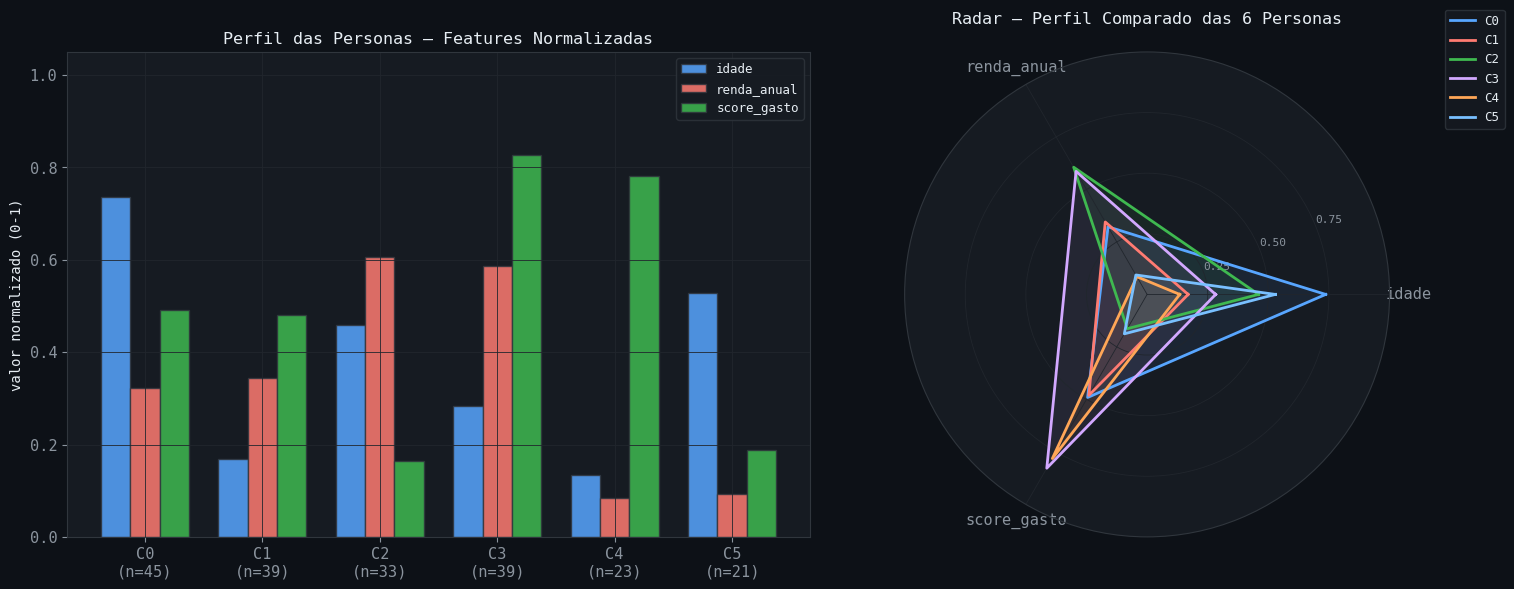

In [7]:
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1)
x = np.arange(len(perfil_norm))
largura = 0.25
for i, col in enumerate(NUMERICAS):
    ax1.bar(x + i * largura, perfil_norm[col], largura,
            label=col, color=PALETTE[i], edgecolor=CORES["borda"], alpha=0.85)
ax1.set_xticks(x + largura)
ax1.set_xticklabels([f"C{c}\n(n={perfil.loc[c, 'n_clientes']})" for c in perfil.index])
ax1.set_ylabel("valor normalizado (0-1)")
ax1.set_title("Perfil das Personas — Features Normalizadas")
ax1.legend()
ax1.set_ylim(0, 1.05)

ax2 = fig.add_subplot(1, 2, 2, polar=True)
angulos = [n / len(NUMERICAS) * 2 * pi for n in range(len(NUMERICAS))]
angulos += angulos[:1] 

for idx, c in enumerate(perfil_norm.index):
    valores = perfil_norm.loc[c].tolist()
    valores += valores[:1]
    ax2.plot(angulos, valores, color=PALETTE[idx], linewidth=2, label=f"C{c}")
    ax2.fill(angulos, valores, color=PALETTE[idx], alpha=0.08)

ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(NUMERICAS)
ax2.set_yticks([0.25, 0.5, 0.75])
ax2.set_yticklabels(["0.25", "0.50", "0.75"], color=CORES["texto2"], fontsize=8)
ax2.set_ylim(0, 1)
ax2.set_title("Radar — Perfil Comparado das 6 Personas", pad=20)
ax2.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.savefig(FIG_DIR / "nb05_perfil_personas.png", dpi=120, bbox_inches="tight")
plt.show()

Com base nos dados acima, podemos nomear os clusters da seguinte forma:

| Cluster | Persona | Perfil | Leitura de negócio |
|---|---|---|---|
| C0 | Maduros Equilibrados | 56 anos, renda e gasto medianos | Base estável e fiel; clientes de meia-idade com consumo moderado |
| C1 | Jovens Equilibrados | 27 anos, renda e gasto medianos | Espelho jovem do C0; potencial de crescimento ao longo do tempo |
| C2 | Abastados Conservadores | Renda alta (89), gasto baixo (17) | Alto poder aquisitivo, mas baixa conversão; grande oportunidade de ativação |
| C3 | Premium | Renda alta (87), gasto alto (82) | Clientes de maior valor; foco em retenção, fidelização e experiências exclusivas |
| C4 | Jovens Impulsivos | 25 anos, renda baixa (25), gasto alto (78) | Gastam acima da média para sua renda; sensíveis a tendências, promoções e influência social |
| C5 | Econômicos | Renda baixa (26), gasto baixo (19) | Consumo contido; margem reduzida, atração baseada em valor e descontos |

### Etapa 5 — Mapeamento de personas

In [8]:
PERSONAS = {
    0: "Maduros Equilibrados",
    1: "Jovens Equilibrados",
    2: "Abastados Conservadores",
    3: "Premium",
    4: "Jovens Impulsivos",
    5: "Econômicos",
}

PERSONAS_DESC = {
    0: "Meia-idade, renda e gasto medianos — base estável e fiel",
    1: "Jovens, renda e gasto medianos — potencial de crescimento",
    2: "Renda alta, gasto baixo — alto poder, baixa conversão",
    3: "Renda alta, gasto alto — clientes-ouro, foco de retenção",
    4: "Jovens, renda baixa, gasto alto — sensíveis a tendência/promoção",
    5: "Renda baixa, gasto baixo — consumo contido, atrair por valor",
}

df_clusterizado["persona"] = df_clusterizado["cluster"].map(PERSONAS)

df_clusterizado.head()

,genero,idade,renda_anual,score_gasto,cluster,persona
id_cliente,,,,,,
1,Male,19,15,39,4,Jovens Impulsivos
2,Male,21,15,81,4,Jovens Impulsivos
3,Female,20,16,6,5,Econômicos
4,Female,23,16,77,4,Jovens Impulsivos
5,Female,31,17,40,5,Econômicos


### Etapa 6 - Cruzamento Persona × Gênero

In [9]:
ct = pd.crosstab(df_clusterizado["persona"], df_clusterizado["genero"])
ct

genero,Female,Male
persona,,
Abastados Conservadores,14,19
Econômicos,13,8
Jovens Equilibrados,25,14
Jovens Impulsivos,13,10
Maduros Equilibrados,26,19
Premium,21,18


In [10]:
ct_pct = pd.crosstab(
    df_clusterizado["persona"], df_clusterizado["genero"], normalize="index"
).mul(100).round(1)

print("═" * 50)
print("CONTAGEM — Persona × Gênero")
print("═" * 50)

print(ct.to_string())

══════════════════════════════════════════════════
CONTAGEM — Persona × Gênero
══════════════════════════════════════════════════
genero                   Female  Male
persona                              
Abastados Conservadores      14    19
Econômicos                   13     8
Jovens Equilibrados          25    14
Jovens Impulsivos            13    10
Maduros Equilibrados         26    19
Premium                      21    18


In [11]:
print("\n" + "═" * 50)
print("PROPORÇÃO (%) DENTRO DE CADA PERSONA")
print("═" * 50)

print(ct_pct.to_string())


══════════════════════════════════════════════════
PROPORÇÃO (%) DENTRO DE CADA PERSONA
══════════════════════════════════════════════════
genero                   Female  Male
persona                              
Abastados Conservadores    42.4  57.6
Econômicos                 61.9  38.1
Jovens Equilibrados        64.1  35.9
Jovens Impulsivos          56.5  43.5
Maduros Equilibrados       57.8  42.2
Premium                    53.8  46.2


In [12]:
chi2, p, dof, _ = chi2_contingency(ct)

print("\n" + "═" * 60)
print("TESTE QUI-QUADRADO (H0: gênero independe da persona)")
print("═" * 60)

print(f"   χ² = {chi2:.3f}  ·  gl = {dof}  ·  p = {p:.4f}")
if p < 0.05:
    print("   → rejeita H0: composição de gênero VARIA entre personas")
else:
    print("   → não rejeita H0: gênero distribuído de forma semelhante")


════════════════════════════════════════════════════════════
TESTE QUI-QUADRADO (H0: gênero independe da persona)
════════════════════════════════════════════════════════════
   χ² = 3.938  ·  gl = 5  ·  p = 0.5583
   → não rejeita H0: gênero distribuído de forma semelhante


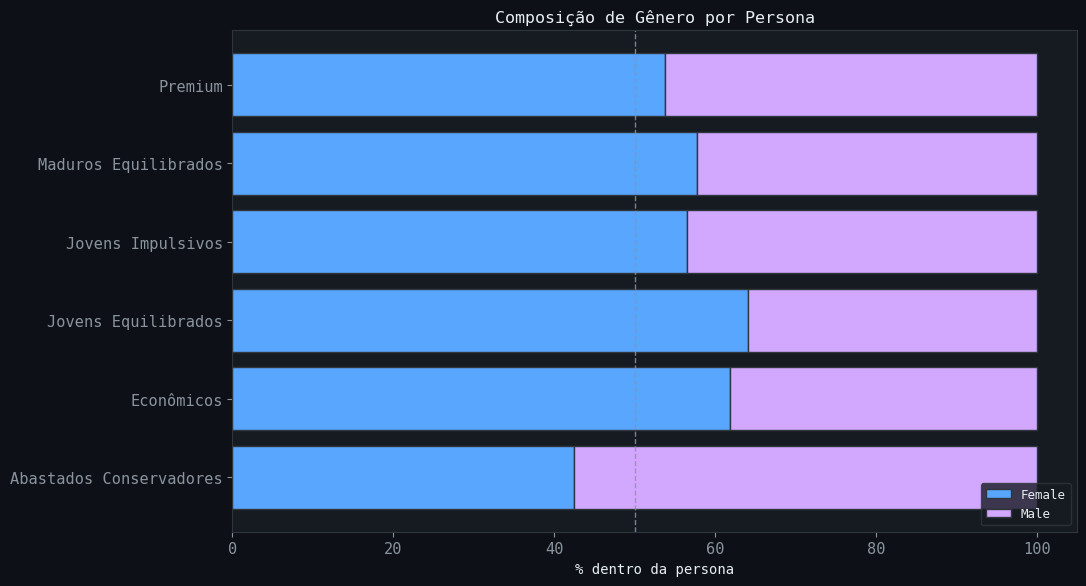

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

generos = ct_pct.columns.tolist()
bottom = np.zeros(len(ct_pct))
cores_genero = [CORES["azul"], CORES["roxo"]]

for i, g in enumerate(generos):
    ax.barh(ct_pct.index, ct_pct[g], left=bottom,
            color=cores_genero[i % 2], label=g, edgecolor=CORES["borda"])
    bottom += ct_pct[g].values

ax.axvline(50, color=CORES["texto2"], linestyle="--", linewidth=1, alpha=0.85)
ax.set_xlabel("% dentro da persona")
ax.set_title("Composição de Gênero por Persona")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIG_DIR / "nb05_persona_genero.png", dpi=120, bbox_inches="tight")
plt.grid(False)
plt.show()

### Etapa 7 — Surrogate DecisionTree 

Para essa etapa, vamos:

- Carregar os splits RAW
- Rotular os clusters atribuídos pelo KMeans

In [14]:
X_treino_raw = pd.read_parquet(DADOS_PRO / "X_treino_raw.parquet")
X_teste_raw  = pd.read_parquet(DADOS_PRO / "X_teste_raw.parquet")

y_treino = pipeline_final.predict(X_treino_raw)
y_teste  = pipeline_final.predict(X_teste_raw)

In [15]:
FEATS = ["idade", "renda_anual", "score_gasto"]
Xtr   = X_treino_raw[FEATS]
Xte   = X_teste_raw[FEATS]

surrogate = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
surrogate.fit(Xtr, y_treino)

acc_treino = accuracy_score(y_treino, surrogate.predict(Xtr))
acc_teste  = accuracy_score(y_teste,  surrogate.predict(Xte))

In [16]:
print("═" * 60)
print("SURROGATE — FIDELIDADE AO KMEANS (max_depth=4)")
print("═" * 60)

print(f"   Acurácia treino : {acc_treino:.1%}")
print(f"   Acurácia teste  : {acc_teste:.1%}  (conjunto não-visto)")
print("\n   (Acurácia = quão bem regras simples reproduzem as fronteiras")
print("    do KMeans; não é 'acerto' supervisionado clássico.)")

════════════════════════════════════════════════════════════
SURROGATE — FIDELIDADE AO KMEANS (max_depth=4)
════════════════════════════════════════════════════════════
   Acurácia treino : 97.5%
   Acurácia teste  : 92.5%  (conjunto não-visto)

   (Acurácia = quão bem regras simples reproduzem as fronteiras
    do KMeans; não é 'acerto' supervisionado clássico.)


In [17]:
print("\n" + "═" * 60)
print("REGRAS EXTRAÍDAS (texto)")
print("═" * 60)
print(export_text(surrogate, feature_names=FEATS))


════════════════════════════════════════════════════════════
REGRAS EXTRAÍDAS (texto)
════════════════════════════════════════════════════════════
|--- score_gasto <= 62.00
|   |--- score_gasto <= 39.50
|   |   |--- renda_anual <= 55.00
|   |   |   |--- score_gasto <= 37.50
|   |   |   |   |--- class: 5
|   |   |   |--- score_gasto >  37.50
|   |   |   |   |--- class: 4
|   |   |--- renda_anual >  55.00
|   |   |   |--- idade <= 19.50
|   |   |   |   |--- class: 1
|   |   |   |--- idade >  19.50
|   |   |   |   |--- class: 2
|   |--- score_gasto >  39.50
|   |   |--- idade <= 43.00
|   |   |   |--- renda_anual <= 33.50
|   |   |   |   |--- class: 4
|   |   |   |--- renda_anual >  33.50
|   |   |   |   |--- class: 1
|   |   |--- idade >  43.00
|   |   |   |--- class: 0
|--- score_gasto >  62.00
|   |--- renda_anual <= 53.50
|   |   |--- class: 4
|   |--- renda_anual >  53.50
|   |   |--- class: 3



Do surrogate, temos as regras usadas nas separações dos clusters:

- `score_gasto > 62` + `renda > 53.5` → Premium (C3). Gasta muito e ganha bem.
- `score_gasto > 62` + `renda ≤ 53.5` → Jovens Impulsivos (C4). Gasta muito apesar da renda baixa.
- `score_gasto ≤ 39.5` + `renda > 55` + `idade > 19.5` → Abastados Conservadores (C2). Ganha bem, gasta pouco.
- `score_gasto ≤ 37.5` + `renda ≤ 55` → Econômicos (C5). Pouco de tudo.
- `score_gasto` médio + `idade > 43` → Maduros Equilibrados (C0); idade ≤ 43 → Jovens Equilibrados (C1).

### Etapa 8 — Visualização: árvore surrogate + clusters no PCA

In [18]:
features_2d = pd.read_parquet(DADOS_PRO / "features_2d_scaled.parquet")
features_3d = pd.read_parquet(DADOS_PRO / "features_3d_scaled.parquet")

labels_idx = df_clusterizado.loc[features_2d.index, "cluster"].values

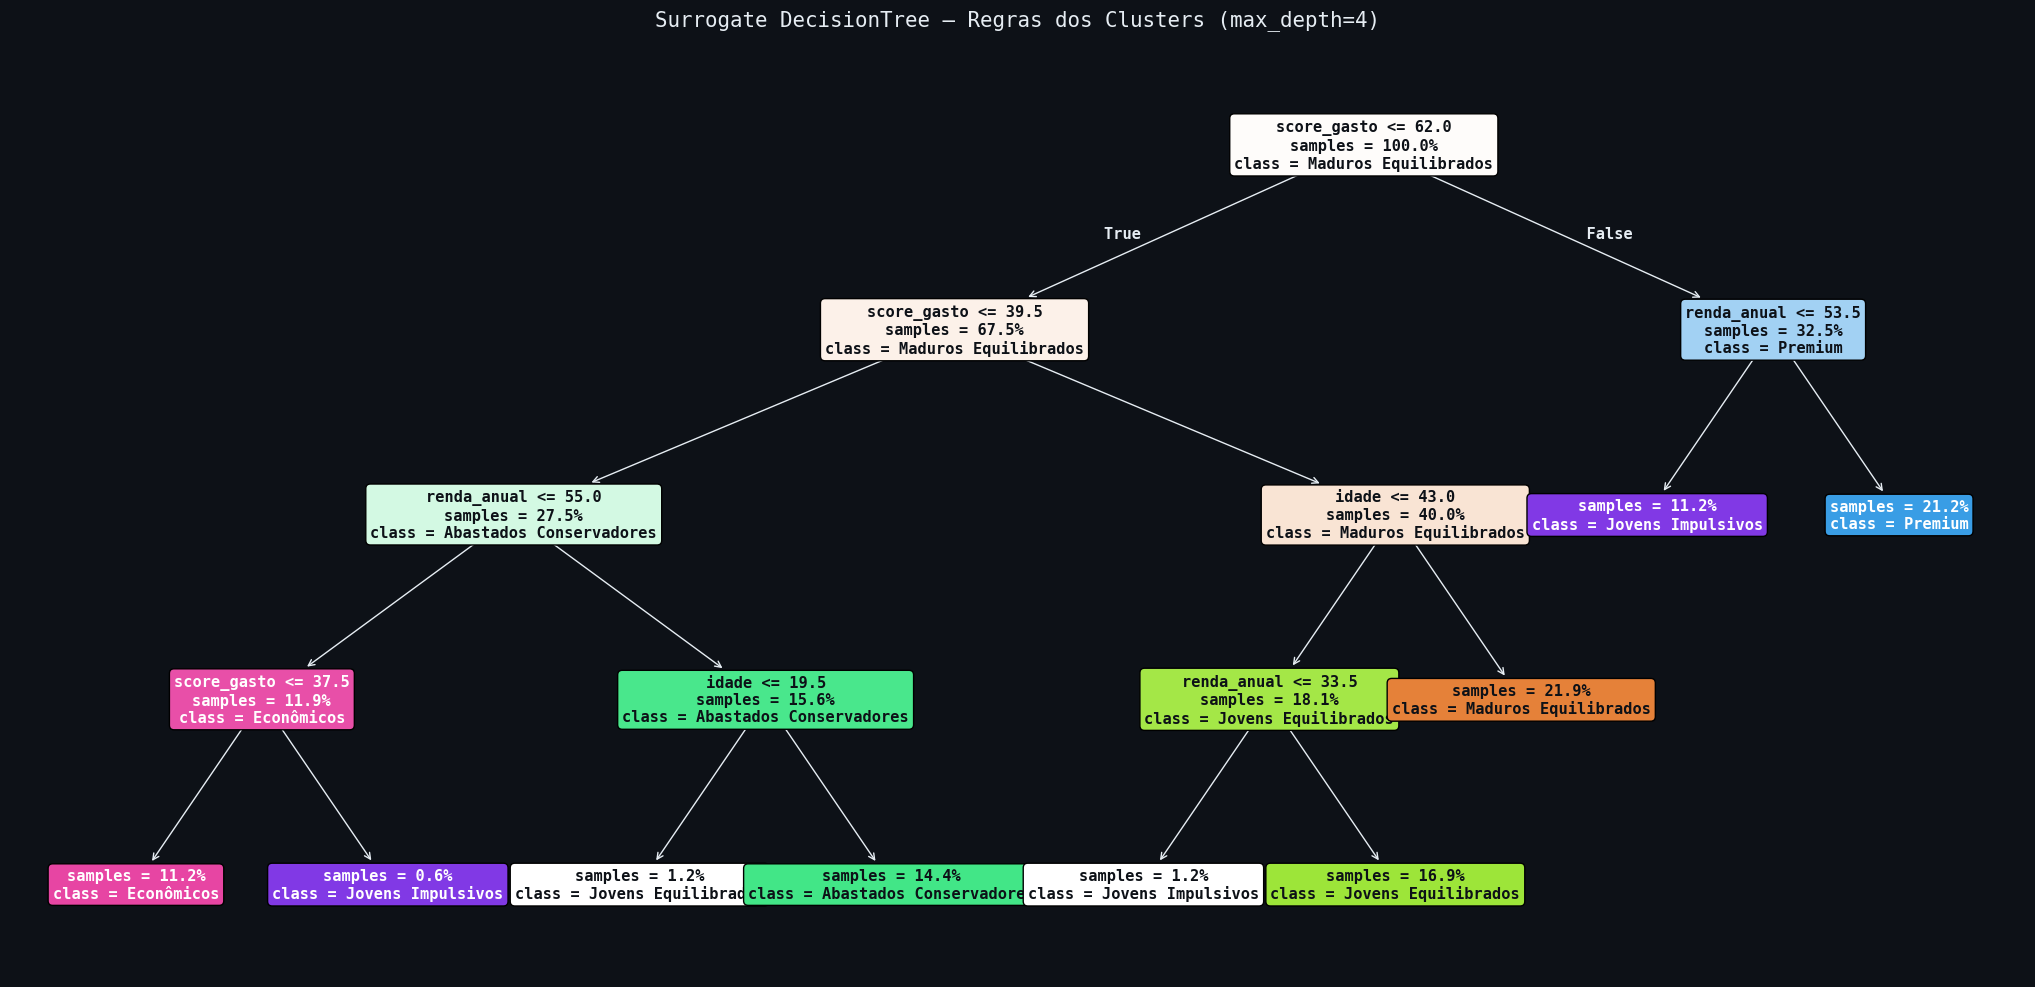

In [19]:
def cor_texto_contraste(rgba):
    r, g, b = rgba[:3]
    return "#0d1117" if (0.299*r + 0.587*g + 0.114*b) > 0.55 else "white"

fig1, ax1 = plt.subplots(figsize=(26, 12))
fig1.patch.set_facecolor(CORES["fundo"])
ax1.set_facecolor(CORES["fundo"])

anotacoes = plot_tree(
    surrogate,
    feature_names=FEATS,
    class_names=[PERSONAS[c] for c in sorted(PERSONAS)],
    filled=True, rounded=True, ax=ax1,
    impurity=False, proportion=True, fontsize=11,
)


for texto in anotacoes:
    conteudo = texto.get_text()
    linhas = [ln for ln in conteudo.split("\n")
              if "value" not in ln and not ln.strip().startswith("[")]
    texto.set_text("\n".join(linhas))
    texto.set_fontweight("bold")

    
    bbox = texto.get_bbox_patch()
    if bbox is not None:
        texto.set_color(cor_texto_contraste(bbox.get_facecolor()))

ax1.set_title("Surrogate DecisionTree — Regras dos Clusters (max_depth=4)",
              fontsize=15, color=CORES["texto"], pad=20)

plt.savefig(FIG_DIR / "nb05_arvore_surrogate.png",
             dpi=110, bbox_inches="tight", facecolor=CORES["fundo"])
plt.show()

C:\Users\jas_t\anaconda3\envs\singularity\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


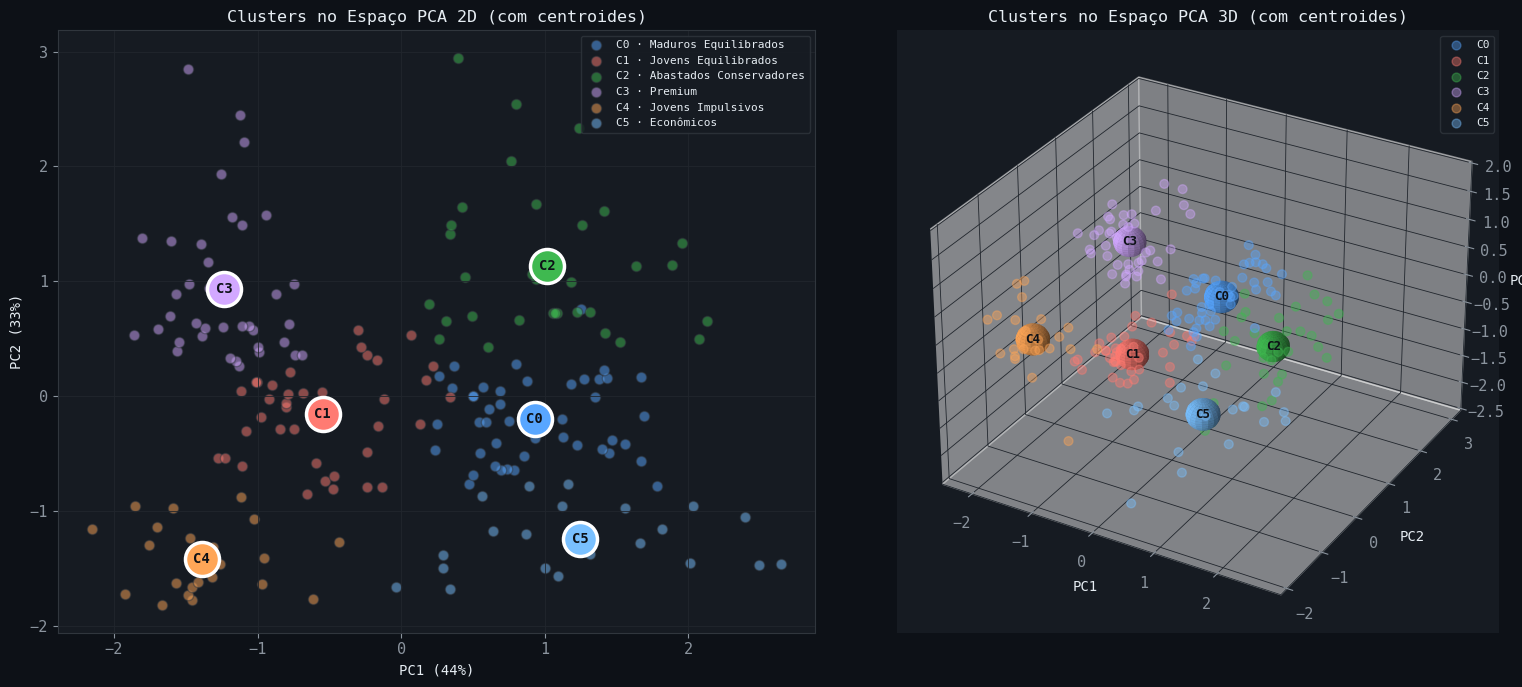

In [20]:
kmeans      = pipeline_final.named_steps["kmeans"]
centroides  = kmeans.cluster_centers_
pca_viz     = joblib.load(MODELS_DIR / "pca_visualizacao.pkl")
cent_pca    = pca_viz.transform(centroides)


def cor_texto_contraste(cor_hex):
    r, g, b = mcolors.to_rgb(cor_hex)
    luminancia = 0.299 * r + 0.587 * g + 0.114 * b
    return "#0d1117" if luminancia > 0.5 else "white"


fig2 = plt.figure(figsize=(16, 7))

ax2 = fig2.add_subplot(1, 2, 1)
for c in sorted(np.unique(labels_idx)):
    m = labels_idx == c
    ax2.scatter(features_2d.values[m, 0], features_2d.values[m, 1], color=PALETTE[c], s=55, 
                alpha=0.50, edgecolor=CORES["borda"], label=f"C{c} · {PERSONAS[c]}")

for c in range(len(cent_pca)):
    ax2.scatter(cent_pca[c, 0], cent_pca[c, 1], s=600, facecolor=PALETTE[c],
                edgecolor="white", linewidth=2.5, zorder=10)
    ax2.annotate(f"C{c}", (cent_pca[c, 0], cent_pca[c, 1]), color=cor_texto_contraste(PALETTE[c]),
                 fontweight="bold", fontsize=10, ha="center", va="center", zorder=11)
    
ax2.set_xlabel("PC1 (44%)")
ax2.set_ylabel("PC2 (33%)")
ax2.set_title("Clusters no Espaço PCA 2D (com centroides)")
ax2.legend(fontsize=8, loc="best")



ax3 = fig2.add_subplot(1, 2, 2, projection="3d")
for c in sorted(np.unique(labels_idx)):
    m = labels_idx == c
    ax3.scatter(features_3d.values[m, 0], features_3d.values[m, 1], features_3d.values[m, 2],
                color=PALETTE[c], s=40, alpha=0.40, label=f"C{c}")

def desenhar_esfera(ax, centro, raio, cor):
    u = np.linspace(0, 2 * np.pi, 18)
    v = np.linspace(0, np.pi, 18)
    x = centro[0] + raio * np.outer(np.cos(u), np.sin(v))
    y = centro[1] + raio * np.outer(np.sin(u), np.sin(v))
    z = centro[2] + raio * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, color=cor, alpha=0.95,
                    edgecolor="none", zorder=10, shade=True)

raio = 0.05 * (features_3d.values[:, 0].max() - features_3d.values[:, 0].min())
for c in range(len(cent_pca)):
    desenhar_esfera(ax3, cent_pca[c], raio, PALETTE[c])
    ax3.text(cent_pca[c, 0], cent_pca[c, 1], cent_pca[c, 2], f"C{c}",
             color=cor_texto_contraste(PALETTE[c]),
             fontweight="bold", fontsize=9,
             ha="center", va="center", zorder=20)

ax3.set_xlabel("PC1")
ax3.set_ylabel("PC2")
ax3.set_zlabel("PC3")
ax3.set_title("Clusters no Espaço PCA 3D (com centroides)")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb05_clusters_pca.png",
             dpi=120, bbox_inches="tight", facecolor=CORES["fundo"])
plt.show()

### Etapa 9 — Re-salvar clusterizado + exportar dicionário de personas

In [21]:
CAMINHO_CLUSTERS = DADOS_PRO / "dados_clusterizados.parquet"
df_clusterizado.to_parquet(CAMINHO_CLUSTERS, index=True)

In [22]:
personas_export = {
    str(c): {"nome": PERSONAS[c], "descricao": PERSONAS_DESC[c]}
    for c in sorted(PERSONAS)
}
CAMINHO_PERSONAS = MODELS_DIR / "personas.json"
with open(CAMINHO_PERSONAS, "w", encoding="utf-8") as f:
    json.dump(personas_export, f, ensure_ascii=False, indent=2)

In [23]:
print("═" * 60)
print("PERSONAS PERSISTIDAS")
print("═" * 60)
print(f"   data/processed/dados_clusterizados.parquet  → +coluna persona")
print(f"   models/personas.json                        → dicionário")

════════════════════════════════════════════════════════════
PERSONAS PERSISTIDAS
════════════════════════════════════════════════════════════
   data/processed/dados_clusterizados.parquet  → +coluna persona
   models/personas.json                        → dicionário


### Etapa 10 — Fechamento

`MÉTRICAS FINAIS (k=6)`
- Silhouette: 0.428 · Davies-Bouldin: 0.825 · CH: 135.1
- Silhouette por cluster: C3/C4/C0 coesos (~0.50);
- C2/C5 difusos (fronteiras suaves, alguns pts negativos)

`PERSONAS (nomeadas a partir do perfil)`
- C0 Maduros Equilibrados   (45) — meia-idade, médio/médio
- C1 Jovens Equilibrados    (39) — jovem, médio/médio
- C2 Abastados Conservadores(33) — renda alta, gasto baixo
- C3 Premium                (39) — renda alta, gasto alto
- C4 Jovens Impulsivos      (23) — jovem, renda baixa, gasto alto
- C5 Econômicos             (21) — renda baixa, gasto baixo

`PERSONA × GÊNERO`
- Qui-quadrado p=0.558 → gênero NÃO estrutura as personas
- Confirma a decisão (NB01) de excluir genero do KMeans,
    validada nas duas pontas (a priori e a posteriori)

`SURROGATE (DecisionTree max_depth=4)`
- Fidelidade: 97.5% treino · 92.5% teste
- Clusters são explicáveis por regras simples de negócio
-  Redescobriu idade (corte ≤43/>43) separando C0 de C1
    - evidência independente de que k=6 foi acertado

`VISUALIZAÇÕES (reports/figures/)`
- b05_perfil_personas · nb05_persona_genero
- nb05_arvore_surrogate · nb05_clusters_pca

`PRÓXIMO PASSO → NB06 (Exportação)`
- features.parquet com cluster + persona (p/ app)
- Dicionário PERSONAS/PERSONAS_DESC exportado
- relatorio_final.html
- Confirmar pipeline_final.joblib pronto p/ deploy